# 3~14번 폴더 전체 모델 분석 결과 종합 비교

**대상:** 3~8번(6가지 데이터 버전) + 11~14번(연속형 결측 전처리 시나리오 4가지) — 총 **10가지 전처리** × **8개 모델**

- **3번** 결측 제거 없음 (로그 없음) — 연속형 결측: 중앙값
- **4번** 결측 50% 초과 제거 (로그 없음)
- **5번** 결측 80% 초과 제거 (로그 없음)
- **6번** 로그변환 + 결측 제거 없음
- **7번** 로그변환 + 결측 50% 초과 제거
- **8번** 로그변환 + 결측 80% 초과 제거
- **11번** 연속형결측_평균대체 (3번과 동일 데이터, 연속형만 mean 대체)
- **12번** 연속형결측_KNN대체 (KNNImputer)
- **13번** 연속형결측_Iterative대체 (IterativeImputer/MICE)
- **14번** 연속형결측_median+결측플래그 (중앙값 + 결측 여부 0/1 컬럼)

각 버전별·모델별 **AUC, 정확도, F1, 과적합 여부**를 한 테이블/차트로 비교합니다.

**참고:** 1~2번은 데이터 전처리, 9~10번은 성별/배우자 유무별 세부 비교용입니다. 11~14번은 3번과 동일 데이터·분할에 연속형 결측 처리만 바꾼 실험입니다.

**사전 조건:** 3~8번 및 11~14번 폴더에서 각 `new_*.ipynb` 실행 후 `results/*.pkl`이 있으면 위 셀 실행 시 해당 버전까지 모두 로드됩니다. (일부만 있으면 있는 것만 표시)

## 1. 경로 설정 및 전체 결과 로드

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sb

# 3~14번 폴더를 여러 후보 루트에서 찾아 경로 구성 (실행 위치 무관)
_cwd = os.path.abspath(os.getcwd())
_roots = [_cwd, os.path.dirname(_cwd), os.path.join(_cwd, 'itwill_bigdata_final_project')]
_fallback = os.path.join('C:', os.sep, 'itwill_bigdata_final_project-main', 'itwill_bigdata_final_project')
if os.path.isdir(_fallback):
    _roots.append(_fallback)

_version_spec = [
    ('3. 결측 변수 제거 없이 분석 진행', 'v3_nodrop_nolog', '3.결측제거없음(로그X)'),
    ('4. 결측 50% 초과 변수 제거 분석', 'v4_50_nolog', '4.결측50%초과제거(로그X)'),
    ('5. 결측 80% 초과 변수 제거 분석', 'v5_80_nolog', '5.결측80%초과제거(로그X)'),
    ('6. 로그변환_결측제거없음', 'v6_nodrop_log', '6.로그+결측제거없음'),
    ('7. 로그변환_결측50초과제거', 'v7_50_log', '7.로그+결측50%초과제거'),
    ('8. 로그변환_결측80초과제거', 'v8_80_log', '8.로그+결측80%초과제거'),
    ('11. 연속형결측_평균대체', 'v11_mean', '11.연속형결측_평균대체'),
    ('12. 연속형결측_KNN대체', 'v12_knn', '12.연속형결측_KNN대체'),
    ('13. 연속형결측_Iterative대체', 'v13_iter', '13.연속형결측_Iterative대체'),
    ('14. 연속형결측_median+결측플래그', 'v14_median_flag', '14.연속형결측_median+결측플래그'),
]
VERSION_FOLDERS = []
for _fname, _vkey, _vlabel in _version_spec:
    for _r in _roots:
        if _r and os.path.isdir(_r):
            _path = os.path.join(_r, _fname)
            if os.path.isdir(_path):
                VERSION_FOLDERS.append((_vkey, _vlabel, _path))
                break

PKL_NAMES = ['new_로지스틱', 'new_경사하강법', 'new_KNN', 'new_SVM', 'new_랜덤포레스트', 'new_XGBoost', 'new_LightGBM', 'new_CatBoost']

# 버전별·모델별 결과 수집 (3~8: score_df/overfit_status, 11~14: scenario_runner metrics)
all_results = []
for vkey, vlabel, folder in VERSION_FOLDERS:
    res_dir = os.path.join(folder, 'results')
    for pkl_name in PKL_NAMES:
        path = os.path.join(res_dir, pkl_name + '.pkl')
        if os.path.isfile(path):
            with open(path, 'rb') as f:
                data = pickle.load(f)
            model_label = pkl_name.replace('new_', '')
            # 11~14번: scenario_runner 형식 (pipeline, metrics, scenario)
            if 'metrics' in data:
                m = data['metrics']
                row = {
                    '데이터버전': vlabel,
                    '모델': model_label,
                    'overfit_status': 'N/A',
                    '의사결정계수(R2)': np.nan,
                    '정확도(Accuracy)': m.get('accuracy'),
                    '정밀도(Precision)': m.get('precision'),
                    '재현율(Recall)': m.get('recall'),
                    '위양성율(Fallout)': np.nan,
                    '특이성(TNR)': np.nan,
                    'F1 Score': m.get('f1'),
                    'AUC': m.get('auc'),
                }
                all_results.append(row)
            else:
                score_df = data.get('score_df')
                status = data.get('overfit_status', 'N/A')
                if score_df is not None and not score_df.empty:
                    row = {'데이터버전': vlabel, '모델': model_label, 'overfit_status': status}
                    for col in score_df.columns:
                        row[col] = score_df.iloc[0][col]
                    all_results.append(row)
        else:
            print(f'Skip: {vlabel} / {pkl_name}')

df_all = pd.DataFrame(all_results)
print(f'총 {len(df_all)} 행 (데이터버전×모델)')
df_all.head(10)

Skip: 11.연속형결측_평균대체 / new_로지스틱
Skip: 11.연속형결측_평균대체 / new_경사하강법
Skip: 11.연속형결측_평균대체 / new_SVM
Skip: 11.연속형결측_평균대체 / new_랜덤포레스트
Skip: 11.연속형결측_평균대체 / new_XGBoost
Skip: 11.연속형결측_평균대체 / new_LightGBM
Skip: 11.연속형결측_평균대체 / new_CatBoost
Skip: 12.연속형결측_KNN대체 / new_로지스틱
Skip: 12.연속형결측_KNN대체 / new_경사하강법
Skip: 12.연속형결측_KNN대체 / new_KNN
Skip: 12.연속형결측_KNN대체 / new_SVM
Skip: 12.연속형결측_KNN대체 / new_랜덤포레스트
Skip: 12.연속형결측_KNN대체 / new_XGBoost
Skip: 12.연속형결측_KNN대체 / new_LightGBM
Skip: 12.연속형결측_KNN대체 / new_CatBoost
Skip: 13.연속형결측_Iterative대체 / new_로지스틱
Skip: 13.연속형결측_Iterative대체 / new_경사하강법
Skip: 13.연속형결측_Iterative대체 / new_KNN
Skip: 13.연속형결측_Iterative대체 / new_SVM
Skip: 13.연속형결측_Iterative대체 / new_랜덤포레스트
Skip: 13.연속형결측_Iterative대체 / new_XGBoost
Skip: 13.연속형결측_Iterative대체 / new_LightGBM
Skip: 13.연속형결측_Iterative대체 / new_CatBoost
Skip: 14.연속형결측_median+결측플래그 / new_로지스틱
Skip: 14.연속형결측_median+결측플래그 / new_경사하강법
Skip: 14.연속형결측_median+결측플래그 / new_KNN
Skip: 14.연속형결측_median+결측플래그 / new_SVM
Skip: 14.연속형결측_median+결측플래그 / n

,데이터버전,모델,overfit_status,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),재현율(Recall),위양성율(Fallout),특이성(TNR),F1 Score,AUC
0,3.결측제거없음(로그X),로지스틱,✅ 일반화 양호,0.362,0.817,0.690,0.832,0.190,0.810,0.754,0.898
1,3.결측제거없음(로그X),경사하강법,✅ 일반화 양호,0.382,0.827,0.720,0.798,0.158,0.842,0.757,0.897
2,3.결측제거없음(로그X),KNN,⚠ 과대적합,0.322,0.799,0.800,0.540,0.069,0.931,0.645,0.885
3,3.결측제거없음(로그X),SVM,⚠ 판단 보류,0.466,0.850,0.737,0.863,0.156,0.844,0.795,0.922
4,3.결측제거없음(로그X),랜덤포레스트,⚠ 판단 보류,0.507,0.886,0.897,0.748,0.044,0.956,0.815,0.955
5,3.결측제거없음(로그X),XGBoost,✅ 일반화 양호,0.607,0.913,0.865,0.879,0.070,0.930,0.872,0.959
6,3.결측제거없음(로그X),LightGBM,✅ 일반화 양호,0.588,0.905,0.856,0.863,0.074,0.926,0.860,0.955
7,3.결측제거없음(로그X),CatBoost,✅ 일반화 양호,0.610,0.907,0.894,0.822,0.050,0.950,0.856,0.958
8,4.결측50%초과제거(로그X),로지스틱,✅ 일반화 양호,0.323,0.803,0.672,0.810,0.201,0.799,0.735,0.882
9,4.결측50%초과제거(로그X),경사하강법,✅ 일반화 양호,0.323,0.803,0.672,0.810,0.201,0.799,0.735,0.882


## 2. 전체 비교표 (데이터버전 × 모델)

In [2]:
if df_all.empty:
    print('로드된 결과가 없습니다. 3~8번 폴더의 new_*.ipynb를 실행해 results/*.pkl을 생성하세요.')
else:
    display(df_all)

,데이터버전,모델,overfit_status,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),재현율(Recall),위양성율(Fallout),특이성(TNR),F1 Score,AUC
0,3.결측제거없음(로그X),로지스틱,✅ 일반화 양호,0.362,0.817,0.690,0.832,0.190,0.810,0.754,0.898
1,3.결측제거없음(로그X),경사하강법,✅ 일반화 양호,0.382,0.827,0.720,0.798,0.158,0.842,0.757,0.897
2,3.결측제거없음(로그X),KNN,⚠ 과대적합,0.322,0.799,0.800,0.540,0.069,0.931,0.645,0.885
3,3.결측제거없음(로그X),SVM,⚠ 판단 보류,0.466,0.850,0.737,0.863,0.156,0.844,0.795,0.922
4,3.결측제거없음(로그X),랜덤포레스트,⚠ 판단 보류,0.507,0.886,0.897,0.748,0.044,0.956,0.815,0.955
5,3.결측제거없음(로그X),XGBoost,✅ 일반화 양호,0.607,0.913,0.865,0.879,0.070,0.930,0.872,0.959
6,3.결측제거없음(로그X),LightGBM,✅ 일반화 양호,0.588,0.905,0.856,0.863,0.074,0.926,0.860,0.955
7,3.결측제거없음(로그X),CatBoost,✅ 일반화 양호,0.610,0.907,0.894,0.822,0.050,0.950,0.856,0.958
8,4.결측50%초과제거(로그X),로지스틱,✅ 일반화 양호,0.323,0.803,0.672,0.810,0.201,0.799,0.735,0.882
9,4.결측50%초과제거(로그X),경사하강법,✅ 일반화 양호,0.323,0.803,0.672,0.810,0.201,0.799,0.735,0.882


## 3. AUC 피벗 테이블 (데이터버전 × 모델)

In [3]:
auc_col = 'AUC' if 'AUC' in df_all.columns else 'roc_auc'
if auc_col not in df_all.columns:
    print('AUC 컬럼 없음. 사용 가능 컬럼:', list(df_all.columns))
else:
    pivot_auc = df_all.pivot(index='데이터버전', columns='모델', values=auc_col).round(3)
    display(pivot_auc)

모델,CatBoost,KNN,LightGBM,SVM,XGBoost,경사하강법,랜덤포레스트,로지스틱
데이터버전,,,,,,,,
11.연속형결측_평균대체,NaN,0.820,NaN,NaN,NaN,NaN,NaN,NaN
3.결측제거없음(로그X),0.958,0.885,0.955,0.922,0.959,0.897,0.955,0.898
4.결측50%초과제거(로그X),0.914,0.865,0.917,0.891,0.922,0.882,0.908,0.882
5.결측80%초과제거(로그X),0.955,0.888,0.956,0.925,0.958,0.898,0.955,0.898
6.로그+결측제거없음,0.956,0.899,0.953,0.923,0.957,0.912,0.958,0.911
7.로그+결측50%초과제거,0.916,0.879,0.918,0.899,0.921,0.895,0.907,0.893
8.로그+결측80%초과제거,0.956,0.904,0.956,0.924,0.959,0.911,0.956,0.910


## 4. AUC 히트맵 (데이터버전 × 모델)

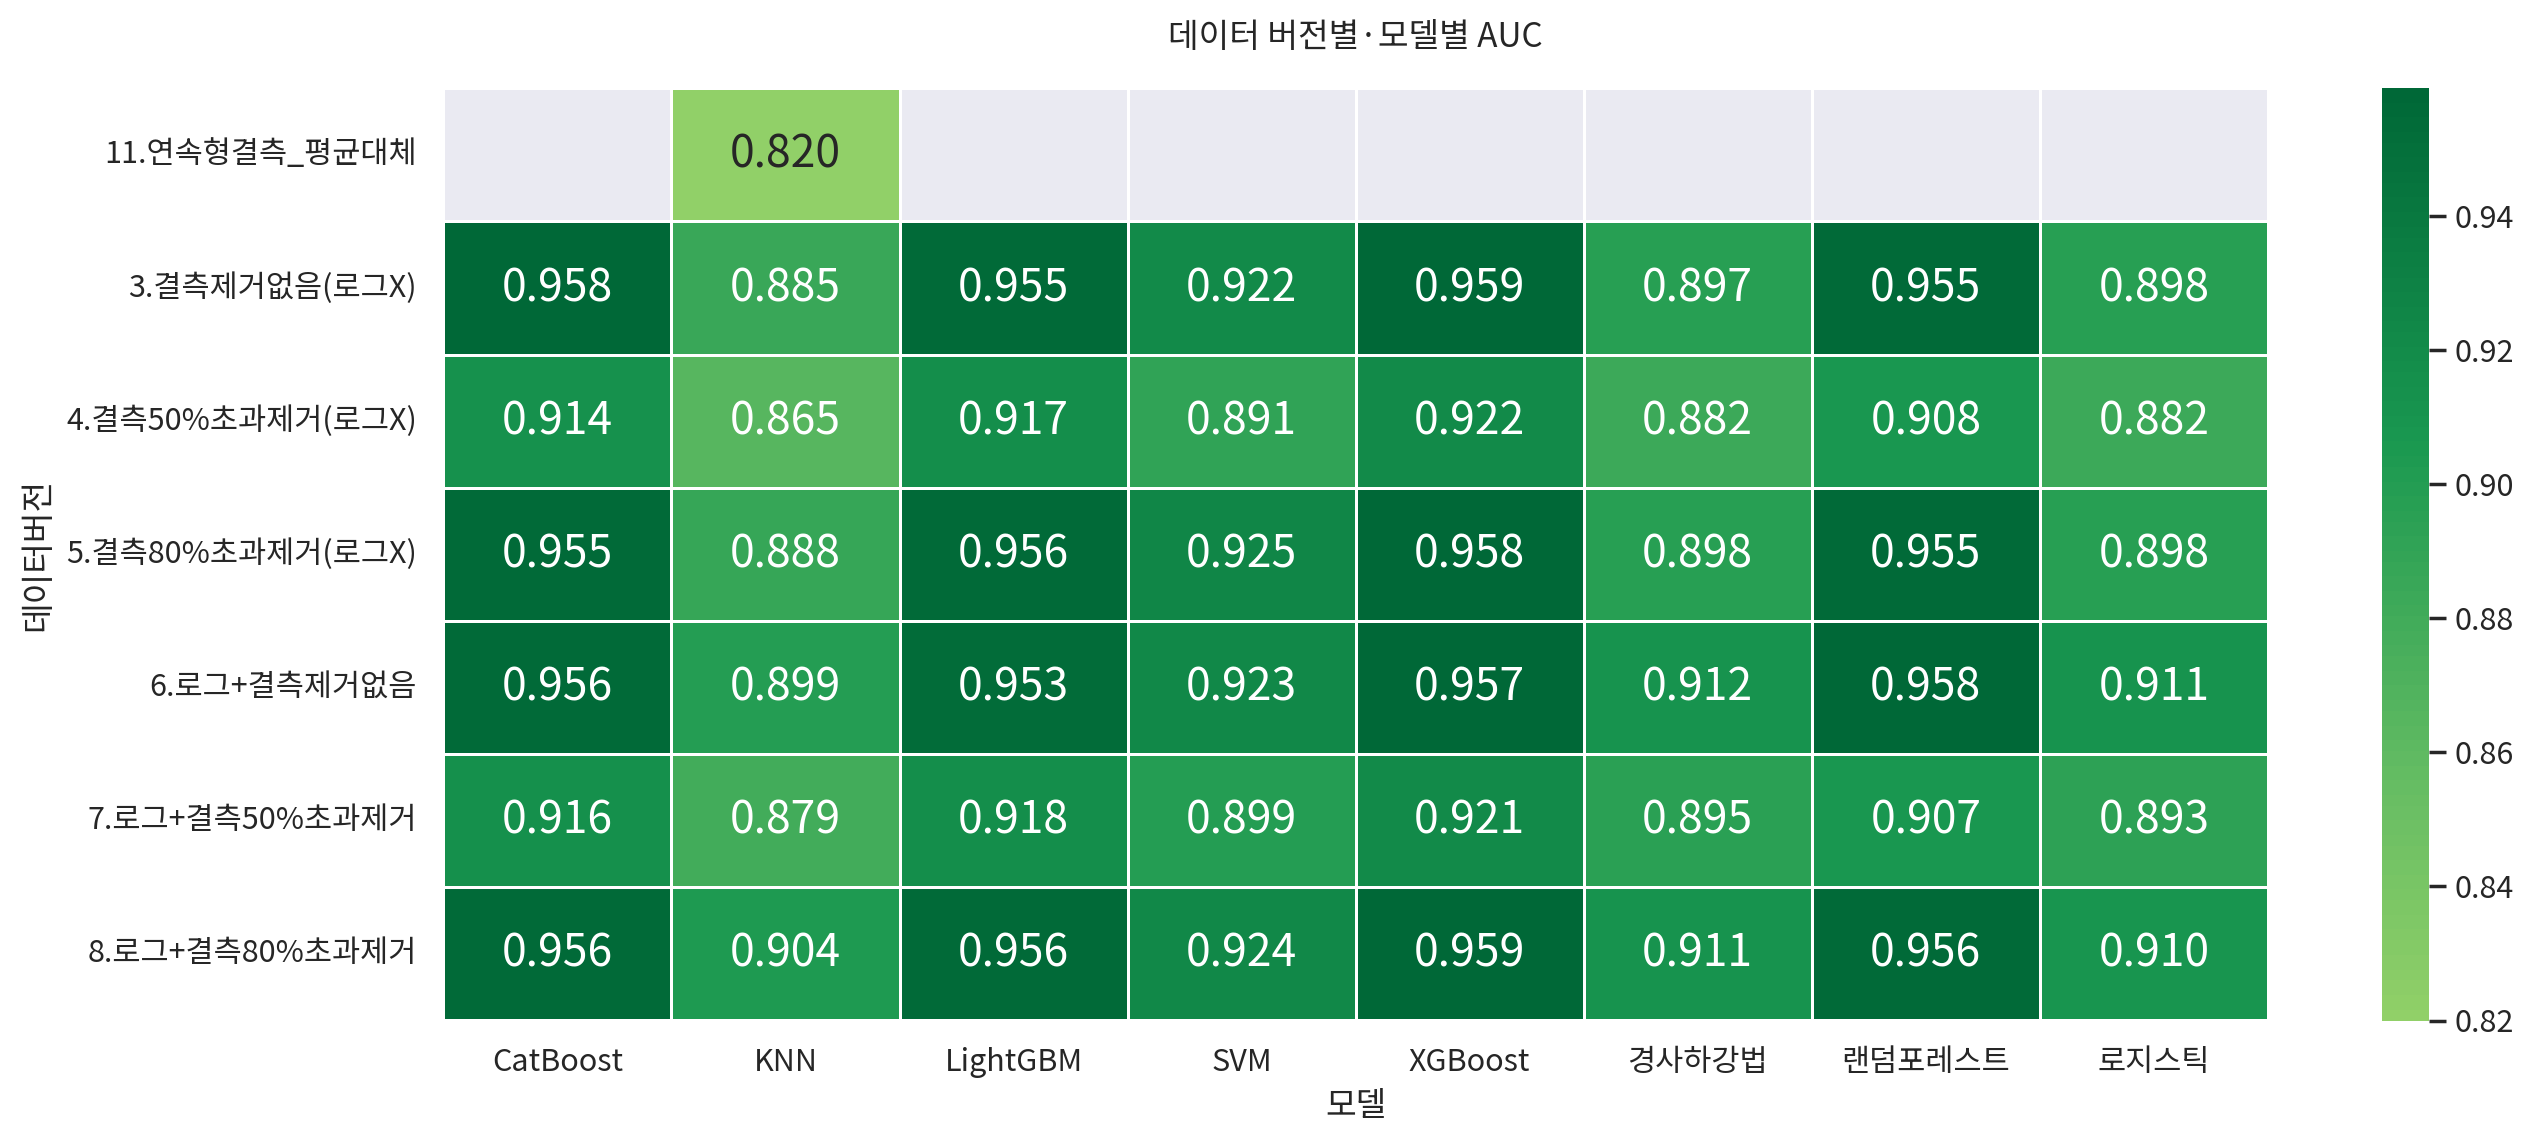

In [4]:
if auc_col in df_all.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    sb.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='RdYlGn', center=0.7, ax=ax, linewidths=0.5)
    ax.set_title('데이터 버전별·모델별 AUC')
    plt.tight_layout()
    plt.show()

## 5. 데이터 버전별 최고 AUC 모델

In [5]:
if auc_col in df_all.columns:
    best_per_version = df_all.loc[df_all.groupby('데이터버전')[auc_col].idxmax()]
    display(best_per_version[['데이터버전', '모델', auc_col, 'overfit_status']])

,데이터버전,모델,AUC,overfit_status
48,11.연속형결측_평균대체,KNN,0.820,N/A
5,3.결측제거없음(로그X),XGBoost,0.959,✅ 일반화 양호
13,4.결측50%초과제거(로그X),XGBoost,0.922,⚠ 판단 보류
21,5.결측80%초과제거(로그X),XGBoost,0.958,✅ 일반화 양호
28,6.로그+결측제거없음,랜덤포레스트,0.958,⚠ 판단 보류
37,7.로그+결측50%초과제거,XGBoost,0.921,⚠ 판단 보류
45,8.로그+결측80%초과제거,XGBoost,0.959,✅ 일반화 양호


## 6. 모델별 AUC 막대그래프 (데이터 버전 구분)

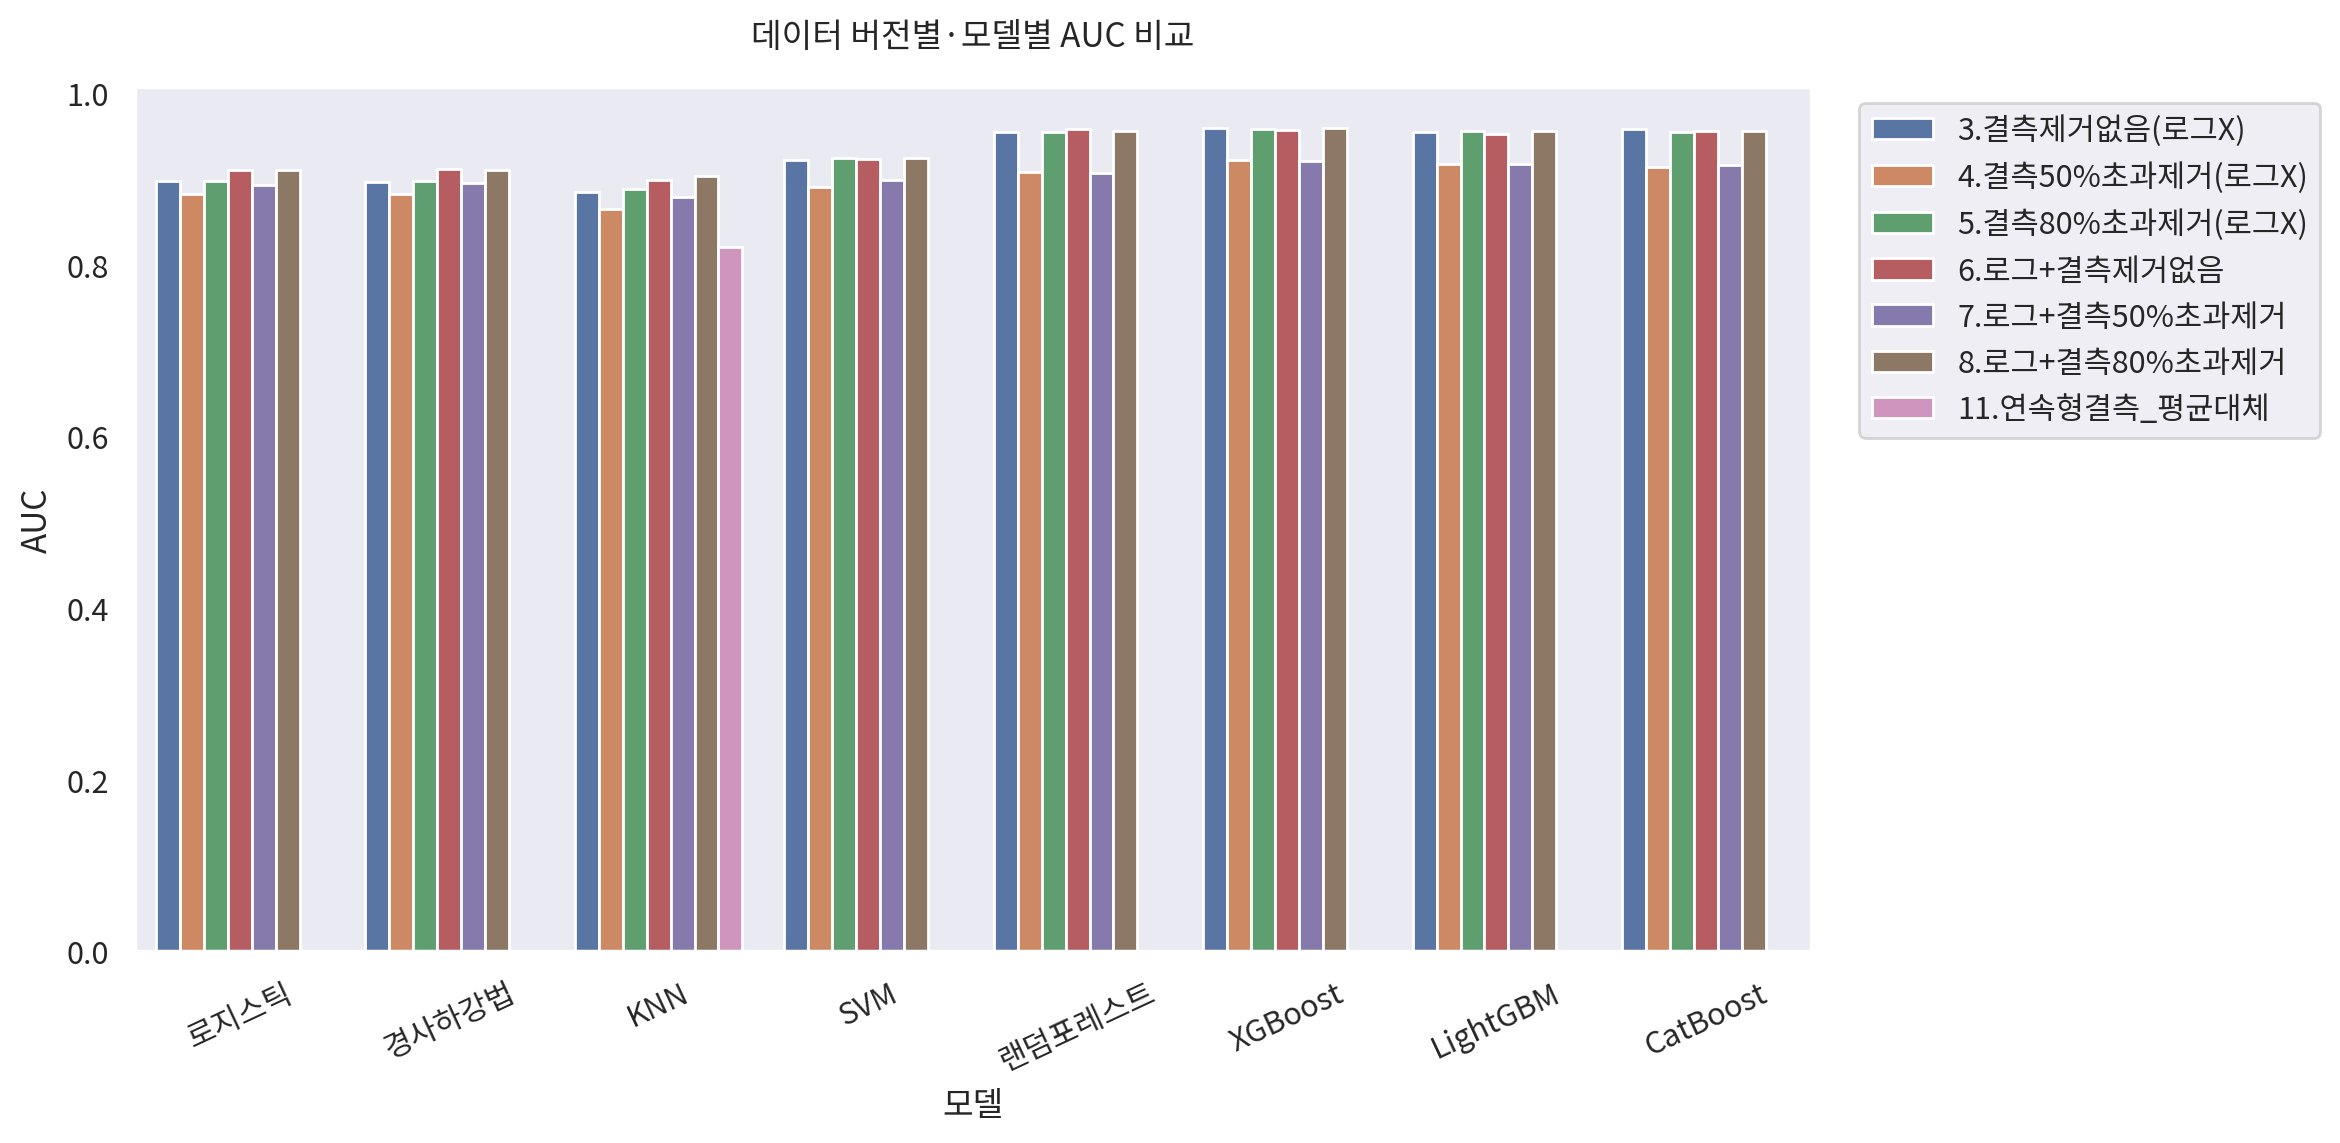

In [6]:
if auc_col in df_all.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    sb.barplot(data=df_all, x='모델', y=auc_col, hue='데이터버전', ax=ax)
    ax.set_ylabel('AUC')
    ax.set_title('데이터 버전별·모델별 AUC 비교')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

## 7. 정확도(Accuracy) 피벗 (선택)

In [7]:
acc_col = '정확도(Accuracy)' if '정확도(Accuracy)' in df_all.columns else None
if acc_col:
    pivot_acc = df_all.pivot(index='데이터버전', columns='모델', values=acc_col).round(3)
    display(pivot_acc)
else:
    print('정확도 컬럼 없음')

모델,CatBoost,KNN,LightGBM,SVM,XGBoost,경사하강법,랜덤포레스트,로지스틱
데이터버전,,,,,,,,
11.연속형결측_평균대체,NaN,0.768,NaN,NaN,NaN,NaN,NaN,NaN
3.결측제거없음(로그X),0.907,0.799,0.905,0.850,0.913,0.827,0.886,0.817
4.결측50%초과제거(로그X),0.850,0.794,0.851,0.828,0.853,0.803,0.843,0.803
5.결측80%초과제거(로그X),0.902,0.802,0.912,0.853,0.905,0.816,0.881,0.816
6.로그+결측제거없음,0.901,0.809,0.899,0.853,0.902,0.837,0.889,0.844
7.로그+결측50%초과제거,0.852,0.810,0.852,0.820,0.855,0.830,0.845,0.805
8.로그+결측80%초과제거,0.899,0.817,0.900,0.853,0.910,0.836,0.883,0.844


## 8. 과적합 여부 요약 (데이터버전 × 모델)

In [8]:
if 'overfit_status' in df_all.columns:
    pivot_status = df_all.pivot(index='데이터버전', columns='모델', values='overfit_status')
    display(pivot_status)

모델,CatBoost,KNN,LightGBM,SVM,XGBoost,경사하강법,랜덤포레스트,로지스틱
데이터버전,,,,,,,,
11.연속형결측_평균대체,NaN,N/A,NaN,NaN,NaN,NaN,NaN,NaN
3.결측제거없음(로그X),✅ 일반화 양호,⚠ 과대적합,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호
4.결측50%초과제거(로그X),⚠ 판단 보류,⚠ 과대적합,⚠ 판단 보류,⚠ 판단 보류,⚠ 판단 보류,✅ 일반화 양호,⚠ 과대적합,✅ 일반화 양호
5.결측80%초과제거(로그X),⚠ 판단 보류,⚠ 과대적합,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호
6.로그+결측제거없음,⚠ 판단 보류,⚠ 과대적합,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호
7.로그+결측50%초과제거,⚠ 판단 보류,⚠ 과대적합,⚠ 판단 보류,⚠ 판단 보류,⚠ 판단 보류,✅ 일반화 양호,⚠ 과대적합,✅ 일반화 양호
8.로그+결측80%초과제거,✅ 일반화 양호,⚠ 과대적합,⚠ 판단 보류,⚠ 판단 보류,✅ 일반화 양호,✅ 일반화 양호,⚠ 판단 보류,✅ 일반화 양호


## 9. 요약: 전체 최고 AUC 조합

In [9]:
if auc_col in df_all.columns and not df_all.empty:
    best_row = df_all.loc[df_all[auc_col].idxmax()]
    print('전체 최고 AUC 조합:')
    print(f"  데이터버전: {best_row['데이터버전']}")
    print(f"  모델: {best_row['모델']}")
    print(f"  AUC: {best_row[auc_col]:.4f}")
    print(f"  과적합: {best_row.get('overfit_status', 'N/A')}")

전체 최고 AUC 조합:
  데이터버전: 3.결측제거없음(로그X)
  모델: XGBoost
  AUC: 0.9590
  과적합: ✅ 일반화 양호


## 10. 전체 결과 종합정리

- **데이터버전별 과적합 현황** — 일반화 양호 개수 순 (과적합 안 난 폴더 선택 시 참고)
- **데이터버전별 최고 AUC** 요약
- **연속형 결측 시나리오(11~14번)** 전용 비교
- **전체 Top 10 AUC** 조합

---

## 보고서 채택 방향성 (논문 모방 시 권장)

참고 논문: *「머신러닝 기법을 활용한 고령자 경제활동 및 임금근로 여부에 미치는 영향 요인 탐색」*(2023, KLoSA 기반)  
→ 논문은 **“결측치 처리하였다”**만 기술하고 구체적 방법(평균/중앙값/KNN 등)은 제시하지 않음.  
→ **년도만 바꿔 모방**하는 경우, 아래 중 하나를 선택해 보고서에 **일관되게** 서술하면 됨.

### 1) **3번 — 결측 제거 없음(로그X), 연속형 중앙값** ⭐ 가장 무난
- **장점:** 변수 제거 없이 결측만 처리(연속형 중앙값). 논문의 “결측치 처리”와 해석이 잘 맞고, 재현·검증이 쉬움.
- **보고서 서술 예:** “연속형 결측은 중앙값으로 대체하였으며, 결측 비율이 높은 변수는 제거하지 않고 분석에 포함하였다.”

### 2) **11번 — 연속형결측_평균대체**
- **장점:** 3번과 동일한 데이터·분할에 연속형만 평균 대체. 논문에서 방법을 구체화할 때 “평균 대체”로 통일하고 싶을 때 적합.
- **보고서 서술 예:** “연속형 결측은 평균으로 대체하였다.”

### 3) **14번 — 연속형결측_median+결측플래그**
- **장점:** 결측 여부를 0/1 플래그로 추가해 정보를 보존. 방법론 섹션을 풍부하게 쓸 수 있음.
- **보고서 서술 예:** “연속형 결측은 중앙값으로 대체하고, 결측 여부를 나타내는 이진 변수를 추가하여 모형에 포함하였다.”

### 4) **6번 — 로그변환 + 결측 제거 없음**
- **장점:** 소득·자산 등 금액 변수 비대칭을 완화. 논문에서 “금액 변수 로그변환”을 언급하고 싶을 때 선택.

**정리:**  
- **과적합이 안 난 모델이 많은 폴더**로 선택하려면 → 위 **데이터버전별 과적합 현황** 표에서 **일반화 양호** 개수가 가장 많은 버전을 선택하세요.  
- **논문과 최대한 비슷하게** 쓰려면 → **3번** 또는 **11번** 채택을 권장.  
- **방법론을 더 구체적으로** 강조하려면 → **14번**을 채택해 “중앙값 대체 + 결측 플래그”로 서술.  
- 위 표·피벗에서 해당 버전(3/11/14/6)의 AUC·정확도·F1을 인용해 보고서에 사용하면 됨.

In [10]:
auc_col = 'AUC' if 'AUC' in df_all.columns else ( 'roc_auc' if 'roc_auc' in df_all.columns else None )
if auc_col and not df_all.empty:
    # 0) 데이터버전별 과적합 현황 — 일반화 양호 개수 기준 추천
    if 'overfit_status' in df_all.columns:
        overfit_cnt = df_all.groupby('데이터버전')['overfit_status'].value_counts().unstack(fill_value=0)
        ok_col = [c for c in overfit_cnt.columns if '일반화' in str(c) and '양호' in str(c)]
        if ok_col:
            ok_col = ok_col[0]
            overfit_cnt['일반화_양호_수'] = overfit_cnt[ok_col]
            overfit_cnt = overfit_cnt.sort_values('일반화_양호_수', ascending=False)
            print('=== 데이터버전별 과적합 현황 (과적합 안 난 모델 많은 순) ===')
            display(overfit_cnt)
            best_ver = overfit_cnt.index[0]
            n_ok = int(overfit_cnt['일반화_양호_수'].iloc[0])
            print(f"\n>> 과적합이 안 난 모델이 많은 폴더로 선택하려면 → **{best_ver}** (일반화 양호 {n_ok}개 모델) 추천")
    # 1) 데이터버전별 최고 AUC
    best_per_version = df_all.loc[df_all.groupby('데이터버전')[auc_col].idxmax()]
    print('\n=== 데이터버전별 최고 AUC ===')
    display(best_per_version[['데이터버전', '모델', auc_col, 'overfit_status']])

    # 2) 연속형 결측 시나리오(11~14번)만 비교
    scenario_versions = [v for v in df_all['데이터버전'].unique() if v.startswith(('11.', '12.', '13.', '14.'))]
    if scenario_versions:
        df_1114 = df_all[df_all['데이터버전'].isin(scenario_versions)]
        print('\n=== 연속형 결측 시나리오(11~14번) AUC 피벗 ===')
        display(df_1114.pivot(index='데이터버전', columns='모델', values=auc_col).round(4))
        best_1114 = df_1114.loc[df_1114[auc_col].idxmax()]
        print(f'\n11~14번 중 최고: {best_1114["데이터버전"]} / {best_1114["모델"]} (AUC={best_1114[auc_col]:.4f})')

    # 3) 전체 Top 10 AUC
    top10 = df_all.nlargest(10, auc_col)[['데이터버전', '모델', auc_col, '정확도(Accuracy)', 'F1 Score', 'overfit_status']]
    print('\n=== 전체 Top 10 AUC 조합 ===')
    display(top10)
else:
    print('AUC 컬럼이 없거나 결과가 비어 있습니다.')

=== 데이터버전별 최고 AUC ===


,데이터버전,모델,AUC,overfit_status
48,11.연속형결측_평균대체,KNN,0.820,N/A
5,3.결측제거없음(로그X),XGBoost,0.959,✅ 일반화 양호
13,4.결측50%초과제거(로그X),XGBoost,0.922,⚠ 판단 보류
21,5.결측80%초과제거(로그X),XGBoost,0.958,✅ 일반화 양호
28,6.로그+결측제거없음,랜덤포레스트,0.958,⚠ 판단 보류
37,7.로그+결측50%초과제거,XGBoost,0.921,⚠ 판단 보류
45,8.로그+결측80%초과제거,XGBoost,0.959,✅ 일반화 양호



=== 연속형 결측 시나리오(11~14번) AUC 피벗 ===


모델,KNN
데이터버전,
11.연속형결측_평균대체,0.820



11~14번 중 최고: 11.연속형결측_평균대체 / KNN (AUC=0.8202)

=== 전체 Top 10 AUC 조합 ===


,데이터버전,모델,AUC,정확도(Accuracy),F1 Score,overfit_status
5,3.결측제거없음(로그X),XGBoost,0.959,0.913,0.872,✅ 일반화 양호
45,8.로그+결측80%초과제거,XGBoost,0.959,0.910,0.867,✅ 일반화 양호
7,3.결측제거없음(로그X),CatBoost,0.958,0.907,0.856,✅ 일반화 양호
21,5.결측80%초과제거(로그X),XGBoost,0.958,0.905,0.855,✅ 일반화 양호
28,6.로그+결측제거없음,랜덤포레스트,0.958,0.889,0.823,⚠ 판단 보류
29,6.로그+결측제거없음,XGBoost,0.957,0.902,0.850,✅ 일반화 양호
22,5.결측80%초과제거(로그X),LightGBM,0.956,0.912,0.872,✅ 일반화 양호
31,6.로그+결측제거없음,CatBoost,0.956,0.901,0.848,⚠ 판단 보류
44,8.로그+결측80%초과제거,랜덤포레스트,0.956,0.883,0.808,⚠ 판단 보류
46,8.로그+결측80%초과제거,LightGBM,0.956,0.900,0.849,⚠ 판단 보류
